<div style="width:100%; background-color:181818; color:f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExd3V1ZXhoNTNtYWJtaWg0YXU3MXRlaHZ3aDZyMnNqMnU2cW45Y3p0byZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/KG4S4T3n2qEqgxBEuV/giphy.gif" alt="Beam Oscillation" width="500" style="border-radius:10px;">

  <h3 style="color:ffffff; margin-top:15px;"><b>Simple code for SDOF in free motion</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Seismic Desing</p>
  <p><b>Year:</b> MARCH - 2026</p>

</div>

## Simple Code for SDOF system in free motion

### **Libraries**

In [1]:
import sys
import os
import glob
from pathlib import Path
sys.path.append(os.path.abspath(".."))

In [2]:
# %matplotlib widget
import numpy as np
from numpy.linalg import eig, inv  
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from repo_seismic_desing import *


In [3]:
xo = 3
xvo = 0
wo = 1
dw = 1
wf = 10
to = 0
dt = 0.01
tf = 5

In [4]:
resul = []
w_values = []
T_values = []
f_values = []
for w in np.arange(wo,wf+1,dw):
    T = 2*np.pi / w
    f = 1/T
    simul = Simple_free_motion(xo,xvo,w,to,dt,tf)
    x, t = simul.sim_free_sdof_nodamp()
    resul.append(x)
    w_values.append(w)
    T_values.append(T)
    f_values.append(f)

col_names = [f"Amplitude, w = {w}, T = {T:.3f} [s], f = {f:.3f} [Hz]" for w, T, f in zip(w_values, T_values, f_values)]

X = np.hstack(resul)
tdf = pd.DataFrame(t, columns= ['Time [s]'])
Xdf = pd.DataFrame(X, columns= col_names) 
RES = pd.concat([tdf, Xdf], axis= 1, ignore_index= False)
RES

,Time [s],"Amplitude, w = 1, T = 6.283 [s], f = 0.159 [Hz]","Amplitude, w = 2, T = 3.142 [s], f = 0.318 [Hz]","Amplitude, w = 3, T = 2.094 [s], f = 0.477 [Hz]","Amplitude, w = 4, T = 1.571 [s], f = 0.637 [Hz]","Amplitude, w = 5, T = 1.257 [s], f = 0.796 [Hz]","Amplitude, w = 6, T = 1.047 [s], f = 0.955 [Hz]","Amplitude, w = 7, T = 0.898 [s], f = 1.114 [Hz]","Amplitude, w = 8, T = 0.785 [s], f = 1.273 [Hz]","Amplitude, w = 9, T = 0.698 [s], f = 1.432 [Hz]","Amplitude, w = 10, T = 0.628 [s], f = 1.592 [Hz]"
0,0.00,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
1,0.01,2.999850,2.999400,2.998650,2.997600,2.996251,2.994602,2.992653,2.990405,2.987858,2.985012
2,0.02,2.999400,2.997600,2.994602,2.990405,2.985012,2.978426,2.970648,2.961682,2.951531,2.940200
3,0.03,2.998650,2.994602,2.987858,2.978426,2.966313,2.951531,2.934093,2.914014,2.891313,2.866009
4,0.04,2.997600,2.990405,2.978426,2.961682,2.940200,2.914014,2.883166,2.847706,2.807690,2.763183
...,...,...,...,...,...,...,...,...,...,...,...
495,4.95,0.706144,-2.667573,-1.961939,1.743965,2.782933,-0.433864,-2.987180,-0.972390,2.529415,2.163144
496,4.96,0.735266,-2.639590,-2.029132,1.644956,2.835452,-0.255082,-2.960487,-1.196081,2.374196,2.359857
497,4.97,0.764313,-2.610550,-2.094499,1.543314,2.880883,-0.075383,-2.919293,-1.412121,2.199758,2.532991
498,4.98,0.793285,-2.580466,-2.157981,1.439204,2.919113,0.104588,-2.863801,-1.619128,2.007515,2.680815


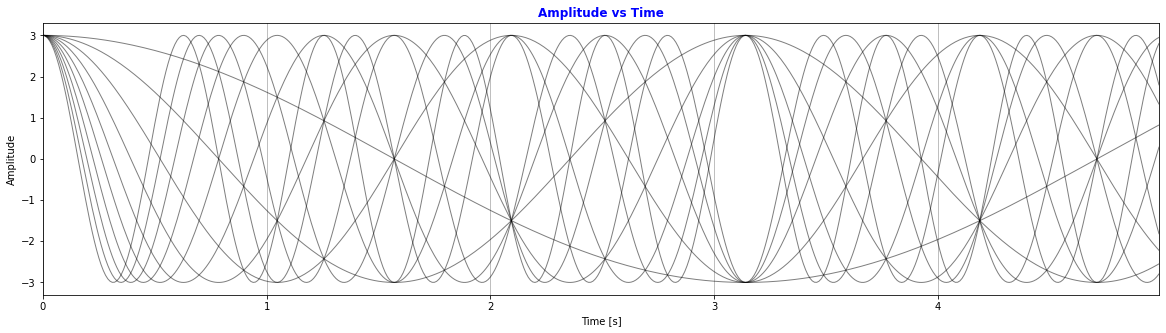

In [5]:
PLTExamp1 = plt_amp_tim(X, t, color = [0, 0, 0], title = 'Amplitude vs Time')
PLTExamp1.plot_Avst()

### Stiffness Comparison

In [6]:
E = 2000000
b1 = 0.30
b2 = 0.40
L = 3
m = 3 / 9.81

facCorr = 1.00

In [7]:
Ic1 = b1**4 / 12
Ic2 = b2**4 / 12

Ic3 = (b1*facCorr)**4/12
Ic4 = (b2*facCorr)**4/12

k1 = 12*E*Ic1 / L**(3)
k2 = 12*E*Ic2 / L**(3)

k3 = 12*E*Ic3 / L**(3)
k4 = 12*E*Ic4 / L**(3)

k1_df = pd.DataFrame({'k1': [k1]})
k2_df = pd.DataFrame({'k2': [k2]})

stiff = pd.concat([k1_df, k2_df], axis=1, ignore_index=False)
stiff

,k1,k2
0,600.0,1896.296296


In [8]:
##---Paralel
keqp = k1 + k2
keqp_df = pd.DataFrame({'Kep [T/m]':[keqp]})
##---Series
Keqs = k3*k4 / (k3+k4)
keqs_df = pd.DataFrame({'Kes [T/m]':[Keqs]})

wp = np.sqrt(keqp / m)
Tp = 2*np.pi / wp
ws = np.sqrt(Keqs / m)
Ts = 2*np.pi / ws

wp_df = pd.DataFrame({'wp': [wp]})
ws_df = pd.DataFrame({'ws': [ws]})
Tp_df = pd.DataFrame({'Tp [s]': [Tp]})
Ts_df = pd.DataFrame({'Ts [s]': [Ts]})

ratioT = Tp / Ts
ratioT_df = pd.DataFrame({'ratio T': [ratioT]})

ratioK = keqp / Keqs
ratioK_df = pd.DataFrame({'ratio K': [ratioK]})

Resul = pd.concat([keqp_df,wp_df, Tp_df,keqs_df, ws_df, Ts_df, ratioT_df, ratioK_df], axis = 1, ignore_index= False)
Resul

,Kep [T/m],wp,Tp [s],Kes [T/m],ws,Ts [s],ratio T,ratio K
0,2496.296296,90.348707,0.069544,455.78635,38.605976,0.162752,0.4273,5.4769


### Displcement Response for damping SDOF system in free motion 

In [9]:
xo = 3
xvo = 0
T = 0.3
zic = 1
zisc = 2
to = 0.0
dt = 0.001
tf = 1.0
zisub = 0.25

w = 2*np.pi/T

#### Critical Damping SDOF system
![alt text](image.png)

#### Over Damping SDOF system
![alt text](image-1.png)

#### Sub Damping SDOF system
![alt text](image-2.png)

In [10]:
#----Critical Damping
xcc = np.zeros(int(tf/dt + 1))
ti = np.zeros(int(tf/dt + 1))
#----Over Damping
ws = w * np.sqrt(zisc**2 - 1)
p1 = -zisc*w - ws
p2 = -zisc*w + ws
C1 = (-xvo + xo*p2)/(p2 - p1)
C2 = (-xvo - xo*p1)/(p2 - p1)
xsc = np.zeros(int(tf/dt + 1))
#----Sub Damping
wsub = w * np.sqrt(1 - zisub**2)
xsub = np.zeros(int(tf/dt + 1))
#----Conservative
Conservative = Simple_free_motion(xo,xvo,w,to,dt,tf)
xcons, tcons = Conservative.sim_free_sdof_nodamp()
 
#----LOOP
j = 0
for t in np.arange(to,tf + dt,dt):
    xcc[j] = (xo * np.exp(-w*t))
    xsc[j] = C1*np.exp(p1*t) + C2*np.exp(p2*t)
    xsub[j] = np.exp(-zisub*w*t)*(xo*np.cos(wsub*t) + (xvo + zisub*w*xo)/(wsub)*np.sin(wsub*t))
    ti[j] = t
    j = j+1
    
xcc = np.vstack(xcc)
xcc_df = pd.DataFrame(xcc, columns= ['Critical Damping Displacement [m]'])
ti_df = pd.DataFrame(ti, columns= ['Time [s]'])

xsc = np.vstack(xsc)
xsc_df = pd.DataFrame(xsc, columns= ['Over Damping Displacement [m]'])

xsub = np.vstack(xsub)
xsub_df = pd.DataFrame(xsub, columns = ['Sub Damping Displacement [m]'])


Resul = pd.concat([ti_df, xcc_df, xsc_df, xsc_df], axis=1, ignore_index= False)
Resul

xcc_vs_t = plt_amp_tim(xcc,ti,[0, 0, 1],'Critical Damping')
xsc_vs_t = plt_amp_tim(xsc,ti,[1, 0, 0],'Over Damping')
xsub_vs_t = plt_amp_tim(xsub,ti,[0, 0, 0],'Sub Damping')
xcons_vs_t = plt_amp_tim(xcons, tcons, [165/255, 42/255, 42/255],'Conservative')

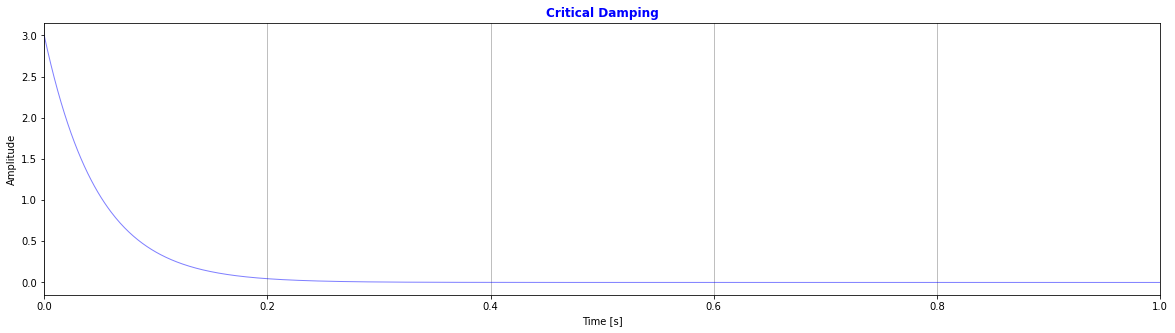

In [11]:
xcc_vs_t.plot_Avst()

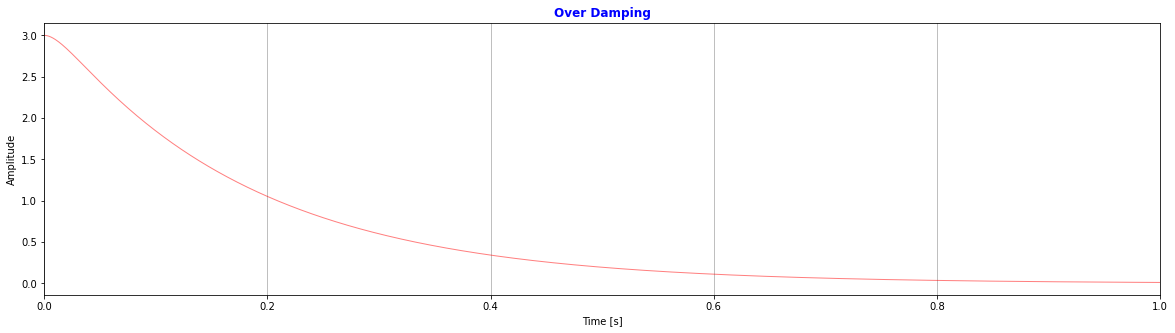

In [12]:
xsc_vs_t.plot_Avst()

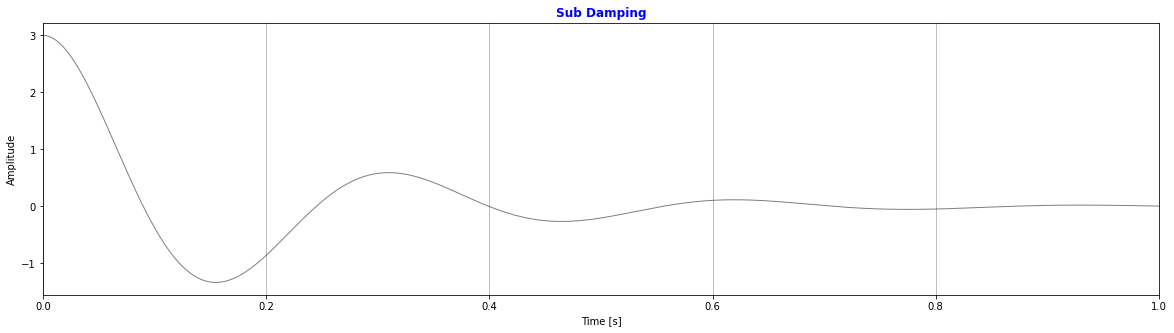

In [13]:
xsub_vs_t.plot_Avst()

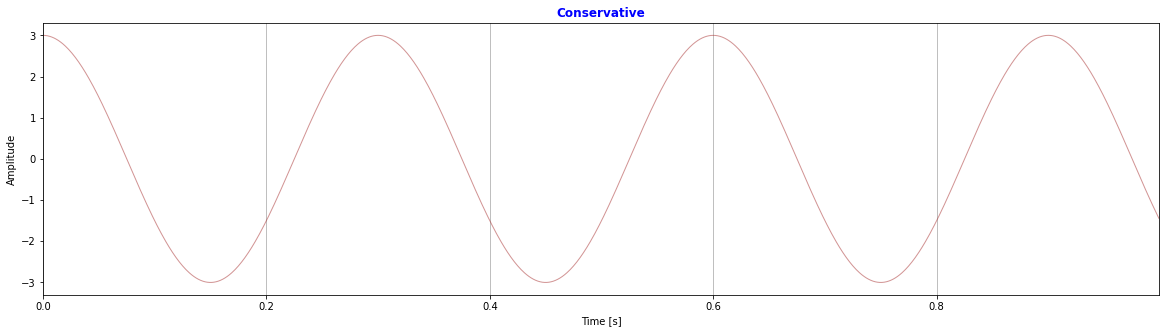

In [14]:
xcons_vs_t.plot_Avst()

##### General Plot


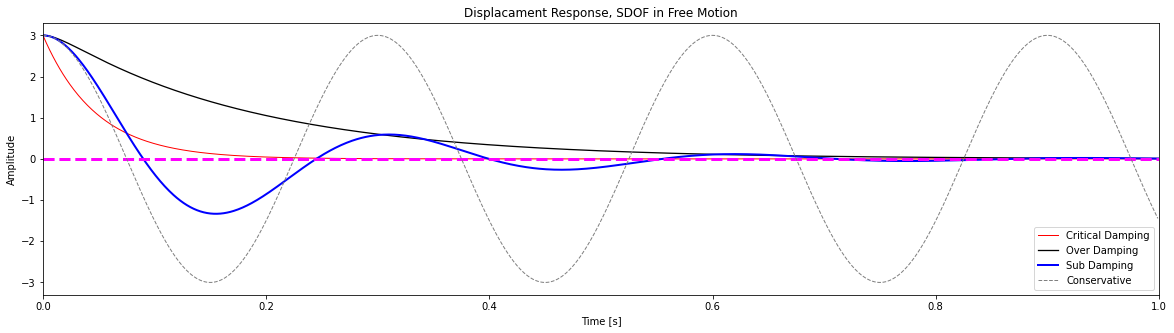

In [15]:
fig, ax = plt.subplots(1,1, figsize = (20,5))
ax.plot(ti, xcc, color = [1,0,0], ls = '-', lw = 1, label = 'Critical Damping')
ax.plot(ti, xsc, color = [0,0,0], ls = '-', lw = 1.3, label = 'Over Damping')
ax.plot(ti, xsub, color = [0,0,1], ls = '-', lw = 2.0, label = 'Sub Damping')
ax.hlines(0, 0, tf, color = [1,0,1], ls = '--', lw = 3.0)
ax.plot(tcons, xcons, color = [0.5,0.5,0.5], ls = '--', lw = 1.0, label = 'Conservative')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')
ax.set_title('Displacament Response, SDOF in Free Motion')
ax.set_xlim([0,ti[-1]])
ax.legend()


### Simple Exercise for SDOF sub damping width real data
![alt text](image-3.png)

* Data

In [16]:
xo = 1
x_cicilo1 = 0.81
xvo = 0
E = 2000000
L = 2.50
col = 0.30
W = 16.25
g = 9.81
to = 0
tf = 3
dt = 0.001

Search_peak = 6

* Solution

In [17]:
m = W / g
I = col**4 / 12
k = 24 * E * I / (L**3)
w = np.sqrt(k / m)
T = 2 * np.pi / w
f = 1 / T
d = np.log(xo / x_cicilo1)
zi = np.sqrt((d**2)/(4 * (np.pi)**2 + d ** 2))

print("="*120)
print(f"Mass: {m:.6f} [Ts2m-1]")
print(f"Stiffness: {k:.6f} [T/m]")
print(f"Angular Frequency: {w:.6f}")
print(f"Period: {T:.6f} [s]")
print(f"Frequency: {f:.6f} [hz]")
print(f"Log Decrement: {d:.6f}")
print("="*120)

ResulExample = Simple_free_motion_sub_damping(T, xo, xvo, zi, to, tf, dt)
xsub, ti = ResulExample.sim_free_sdof_SubDamping()

xsub_df = pd.DataFrame(xsub, columns= ['Displacement [m]'])
ti_df = pd.DataFrame(ti, columns= ['Time [s]'])
Resul = pd.concat([ti_df, xsub_df], axis = 1, ignore_index= False)
Resul

Mass: 1.656473 [Ts2m-1]
Stiffness: 2073.600000 [T/m]
Angular Frequency: 35.381017
Period: 0.177586 [s]
Frequency: 5.631064 [hz]
Log Decrement: 0.210721


,Time [s],Displacement [m]
0,0.000,1.000000
1,0.001,0.999375
2,0.002,0.997501
3,0.003,0.994385
4,0.004,0.990034
...,...,...
2996,2.996,0.017683
2997,2.997,0.018448
2998,2.998,0.019187
2999,2.999,0.019901


* Peaks

In [18]:
Indices_peaks, props = find_peaks(xsub)
peaks = xsub[Indices_peaks]
INDICE_PEAK =Indices_peaks[Search_peak - 1]
TIME = ti[INDICE_PEAK]
PEAK = xsub[INDICE_PEAK]

print("="*120)
print(f"Cicle Number: {Search_peak:.0f}")
print(f"Peak Time: {TIME:.6f} [s]")
print(f"Peak Displacement: {PEAK:.12f} [m]")
print("="*120)

Cicle Number: 6
Peak Time: 1.066000 [s]
Peak Displacement: 0.282427112711 [m]


* Plotting

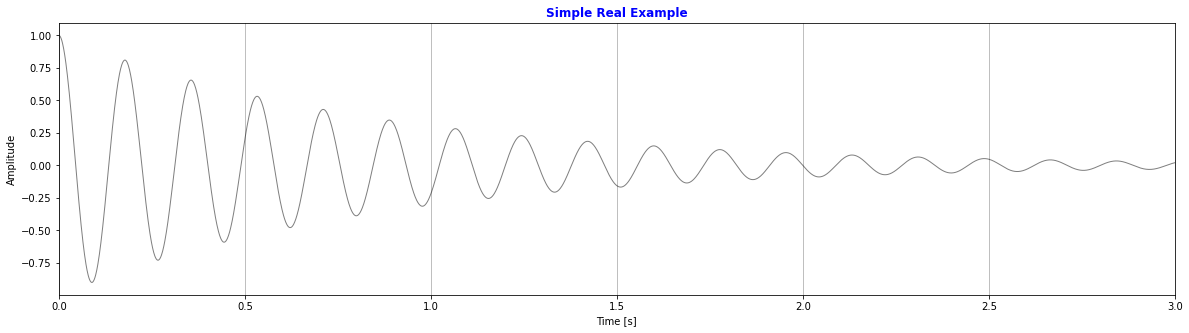

In [19]:
xsub_vs_t = plt_amp_tim(xsub,ti,[0, 0, 0],'Simple Real Example')
xsub_vs_t.plot_Avst()

### Calculation of the displacement response (Transients and Stationary) for a SDOF system
![alt text](image-4.png)

##### Data

In [20]:
to = 0
dt = 0.001
tfe = 2.5
tft = 5.0
T = 0.3
z = 0.4
fa = 1.23
a = z*fa

##### Seismic Excitation

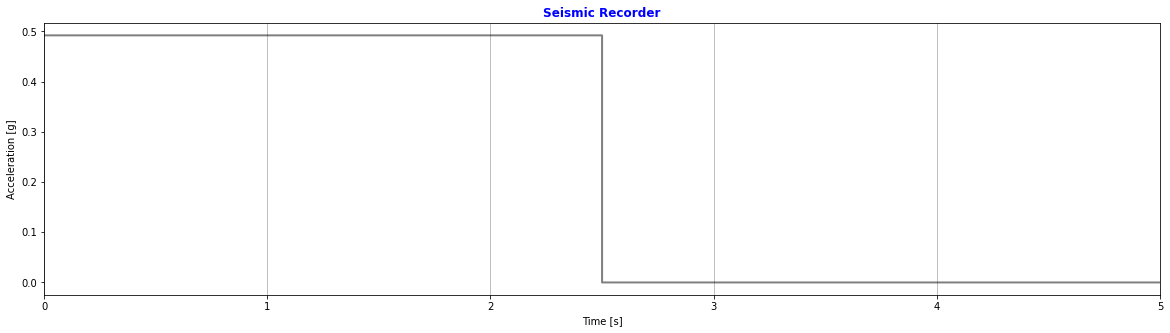

In [21]:
tie = np.zeros(int((tfe-to)/dt) + 1)
Sge = np.zeros(int((tfe-to)/dt) + 1)

j = 0
for t in np.arange(to, tfe + dt, dt):
    tie[j] = t
    Sge[j] = a
    j = j+1

n = int(round((tft - tfe) / dt)) + 1
tit = np.linspace(tfe, tft, n)
Sgt = np.zeros(n)

TI = np.concatenate((tie, tit))
SG = np.concatenate((Sge, Sgt))

Sismo = plt_amp_tim(SG, TI,color = [0, 0, 0], title = 'Seismic Recorder', ylabel= 'Acceleration [g]', grl = 2)
Sismo.plot_Avst()

In [22]:
data = np.column_stack((TI, SG))
np.savetxt("rex_rect_DS_2026_01.txt", data, fmt="%.16f")

##### Stationary Response
![alt text](image-5.png)

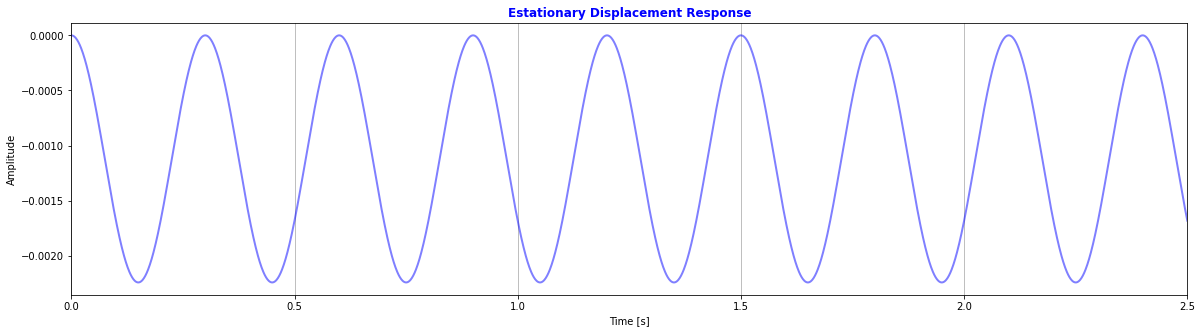

In [23]:
xe = np.zeros(int((tfe-to)/dt) + 1)
w = 2 * np.pi / T
j = 0
for t in np.arange(to, tfe + dt, dt):
    xe[j] = - a / (w**2) * (1 - np.cos(w*t))
    j = j+1

Es = plt_amp_tim(xe, tie,color = [0, 0, 1], title = 'Estationary Displacement Response', ylabel= 'Amplitude', grl = 2)
Es.plot_Avst()


##### Transient Response
![alt text](image-6.png)

xt =  -0.001682438254381021 tit = 2.5 xe =  -0.001682438254381021 tie = 2.5


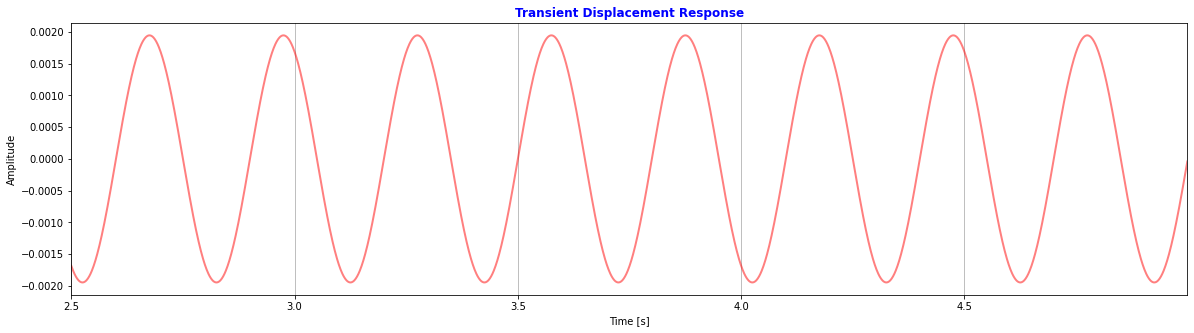

In [24]:
xt = np.zeros(int((tft - tfe)/dt) + 1)
tit = np.zeros(int((tft - tfe)/dt) + 1)

j = 0
for t in np.arange(tfe, tft, dt):
    xt[j] = - a / (w**2) * (np.cos(w*(t-tfe)) - np.cos(w*t))
    tit[j] = t
    j = j+1

xt = xt[0:-1]
tit = tit[0:-1]

print("=" * 120)
print('xt = ',xt[0],'tit =', tit[0],'xe = ', xe[-1],'tie =', tie[-1])
print("=" * 120)

Et = plt_amp_tim(xt, tit,color = [1, 0, 0], title = 'Transient Displacement Response', ylabel= 'Amplitude', grl = 2)
Et.plot_Avst()

##### Plot all displacement response

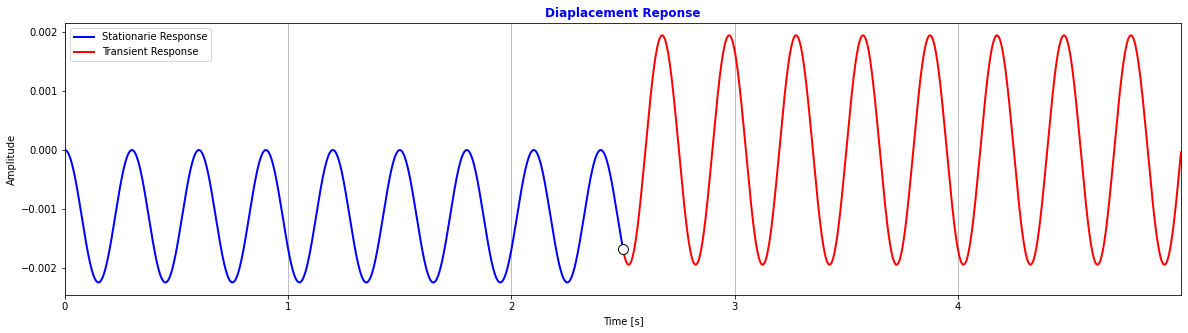

In [25]:
fig, ax = plt.subplots(1,1, figsize = (20,5))
ax.plot(tie, xe, color = (0,0,1), lw = 2.0, label = 'Stationarie Response')
ax.plot(tit, xt, color = (1,0,0), lw = 2.0, label = 'Transient Response')
ax.plot(tie[-1], xe[-1], marker = 'o', markersize = 10, markerfacecolor = (1,1,1), markeredgecolor = (0,0,0))
ax.set_title('Diaplacement Reponse', fontsize = 12, color = [0,0,1], fontweight = 'bold')
ax.set_ylabel('Amplitude')
ax.set_xlabel('Time [s]')
ax.grid(visible= True, axis= 'x')
ax.set_xlim(0, tit[-1])
ax.legend(loc='best')
plt.show()

### Solution B-Newmark (Jr)
![alt text](image-7.png)

#### Data

In [26]:
T = 0.3
M = 1
zi = 0.0
Sg_df = pd.DataFrame(SG,columns=['Acceleration [g]'])
Ti_df = pd.DataFrame(TI,columns=['Time [s]'])
dt = TI[1] - TI[0]
print(dt)
REC = pd.concat([Ti_df,Sg_df], axis=1,ignore_index= False)
REC

0.001


,Time [s],Acceleration [g]
0,0.000,0.492
1,0.001,0.492
2,0.002,0.492
3,0.003,0.492
4,0.004,0.492
...,...,...
4997,4.996,0.000
4998,4.997,0.000
4999,4.998,0.000
5000,4.999,0.000


#### Solution

In [27]:
Resul_Bnewmark = Step_by_Step_BNewmark(T = T,M = M,zi = zi,accel_record= SG,vector_time= TI,
                                       colorSeism=(0,0,0), colorRaccel= (0,1,0), colorRTaccel= (0,0,1))
at, xan1, xvn1, xn1 = Resul_Bnewmark.Bnewmark_Jr() 

xan1_df = pd.DataFrame(xan1, columns=['Acceleration Response [g]'])
xvn1_df = pd.DataFrame(xvn1, columns=['Velocity Response'])
xn1_df = pd.DataFrame(xn1, columns=['Displacement Response'])
at_df = pd.DataFrame(at, columns=['Total Acceleration Response [g]'])

Resul = pd.concat([Ti_df, Sg_df,at_df,xan1_df, xvn1_df, xn1_df], axis=1, ignore_index= False)
Resul

5002


,Time [s],Acceleration [g],Total Acceleration Response [g],Acceleration Response [g],Velocity Response,Displacement Response
0,0.000,0.492,0.000000,-0.492000,0.000000,0.000000e+00
1,0.001,0.492,0.000108,-0.491892,-0.000492,-2.460000e-07
2,0.002,0.492,0.000432,-0.491568,-0.000984,-9.838921e-07
3,0.003,0.492,0.000971,-0.491029,-0.001475,-2.213353e-06
4,0.004,0.492,0.001726,-0.490274,-0.001966,-3.933842e-06
...,...,...,...,...,...,...
4997,4.996,0.000,0.056916,0.056916,0.040730,-1.297519e-04
4998,4.997,0.000,0.039037,0.039037,0.040778,-8.899343e-05
4999,4.998,0.000,0.021141,0.021141,0.040808,-4.819595e-05
5000,4.999,0.000,0.003236,0.003236,0.040820,-7.377327e-06


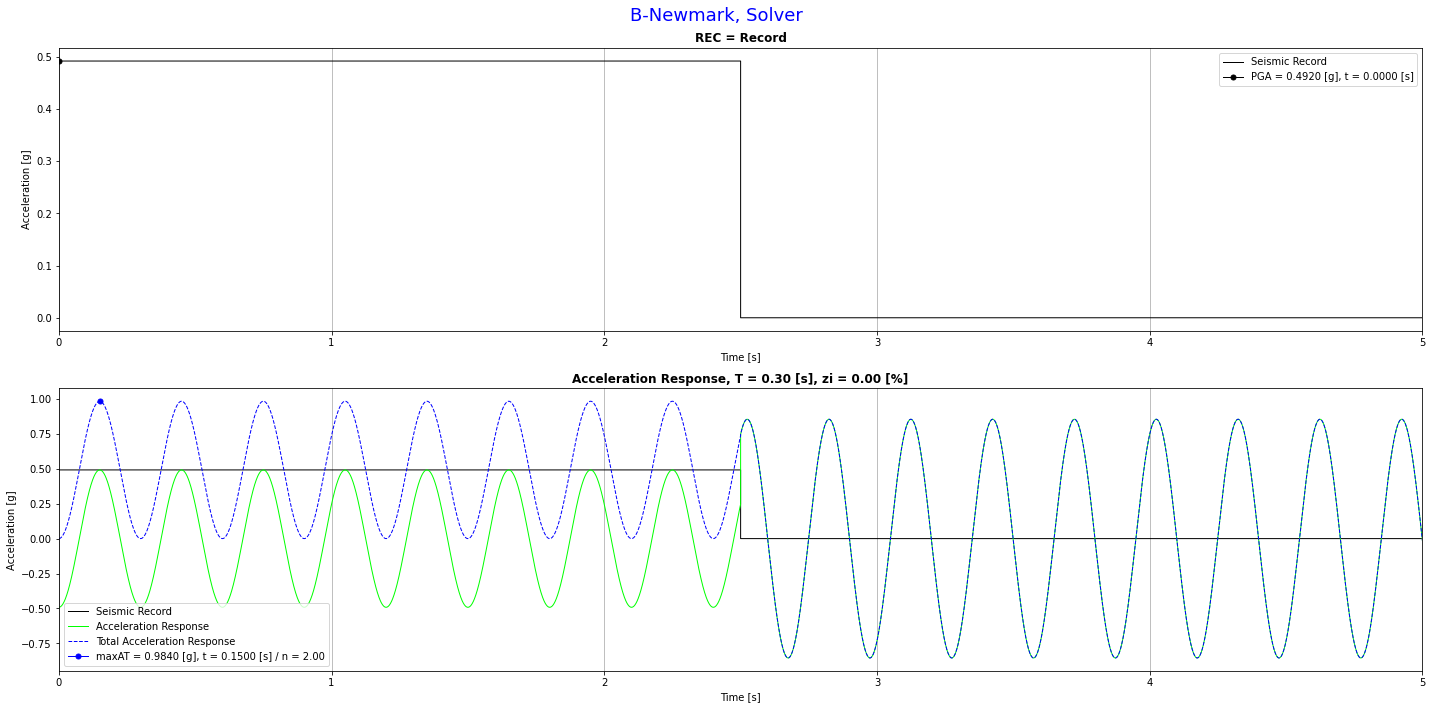

In [28]:
Resul_Bnewmark.plot_seis_Raccel(xan1, at)

#### Displacement Response

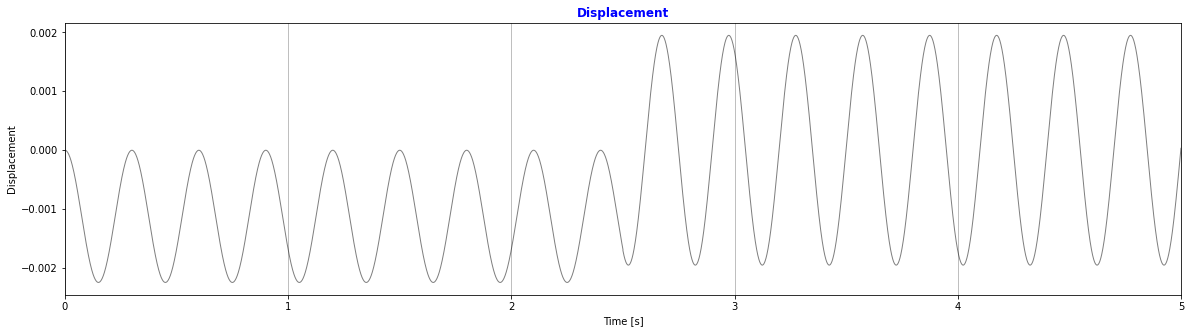

In [29]:
xn1grap = plt_amp_tim(xn1, TI,color = [0,0,0,],title = 'Displacement', ylabel= 'Displacement', grl = 1)
xn1grap.plot_Avst()

#### Velocity Response

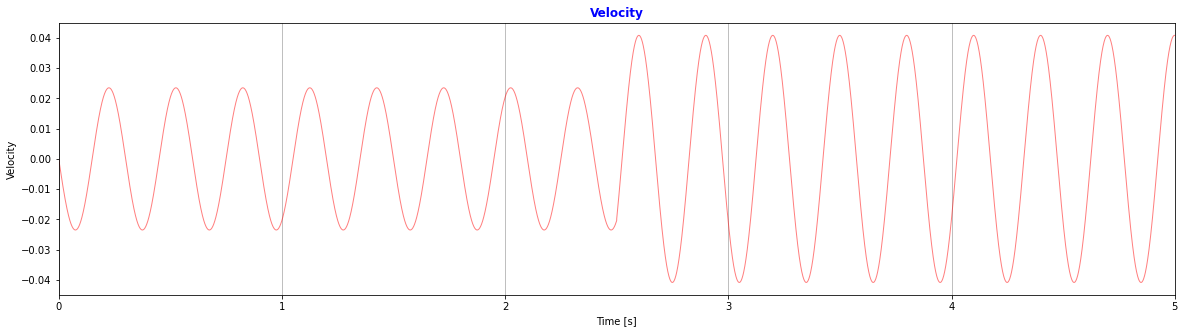

In [30]:
xvn1grap = plt_amp_tim(xvn1, TI,color = [1,0,0],title = 'Velocity', ylabel= 'Velocity', grl = 1)
xvn1grap.plot_Avst()

#### Displacement Comparisson Between Newmark and Exact Solution

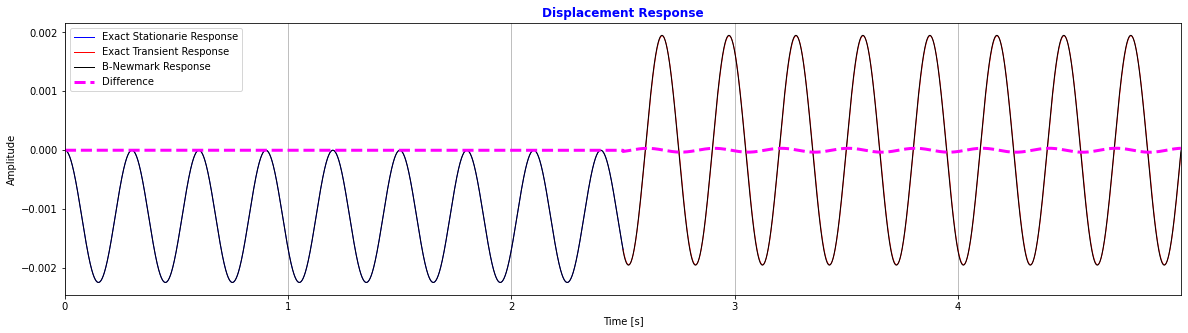

In [31]:
xe_xt = (np.concatenate((xe, xt)))

diff = xn1[0:-1] - xe_xt

fig, ax = plt.subplots(1,1, figsize = (20,5))
ax.plot(tie, xe, color = (0,0,1), lw = 1.0, label = 'Exact Stationarie Response')
ax.plot(tit, xt, color = (1,0,0), lw = 1.0, label = 'Exact Transient Response')
ax.plot(TI, xn1, color = (0,0,0), lw = 1.0, label = 'B-Newmark Response')
ax.plot(TI[0:-1], diff, color = (1,0,1),ls = '--', lw = 3.0, label = 'Difference')
ax.set_title('Displacement Response', fontsize = 12, color = [0,0,1], fontweight = 'bold')
ax.set_ylabel('Amplitude')
ax.set_xlabel('Time [s]')
ax.grid(visible= True, axis= 'x')
ax.set_xlim(0, tit[-1])
ax.legend(loc='best')
plt.show()

### Solution B-Newmark (Jr). for any record [Ti Sg]

#### Directory

In [32]:
project_root = Path.cwd().parent
directory = project_root / "records"
print('=' * 120)
print(directory)
print('=' * 120)

AT2_files = sorted(list(directory.glob("*.AT2")))
AT2_files_df = pd.DataFrame([file.name for file in AT2_files], columns=['AT2 Files'])
AT2_files_df.head(len(AT2_files_df))

c:\Dropbox\Root\Github Repositories\Repo_Seismic_Desing\records


,AT2 Files
0,AMT_201604162359_E_100.AT2
1,Artificial.AT2
2,ChiChi_longt.AT2
3,ChiChi_tranv.AT2
4,DS_GR1_2023_02.AT2
5,DS_GR2_2023_02.AT2
6,Friulli.AT2
7,Hollister.AT2
8,Loma_Prieta_1989.AT2
9,rex_rect_DS_2026_01.AT2


#### Solution and Plot

2054


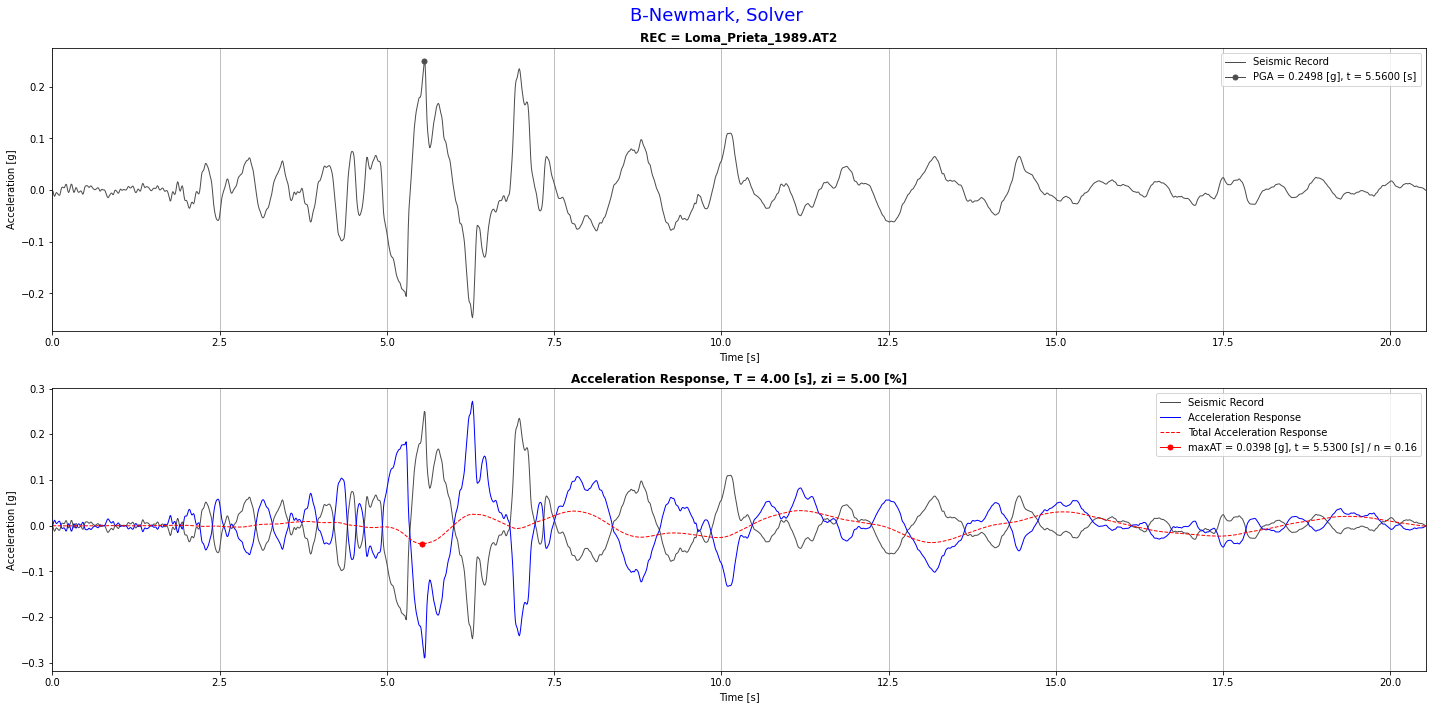

In [33]:
#----------Data------------#
T = 4
M = 1
zi = 0.05
selected_record = 8
title_record = AT2_files[selected_record].name

#----------Record------------#
TI, SG = np.loadtxt(AT2_files[selected_record], unpack= True)

#----------Solution------------#
Resul_Bnewmark = Step_by_Step_BNewmark(T = T,M = M,zi = zi,accel_record= SG,vector_time= TI,
                                       colorSeism=(0.3,0.3,0.3), colorRaccel= (0,0,1), colorRTaccel= (1,0,0), title = title_record)
at, xan1, xvn1, xn1 = Resul_Bnewmark.Bnewmark_Jr() 

#----------Plot------------#
Resul_Bnewmark.plot_seis_Raccel(xan1, at)

### Response Spectrum

In [34]:
#----------Data------------#
To = 0.05
Tf = 4.0
dT = 0.01

M = 1
zi = 0.05
selected_record = 7
title_record = AT2_files[selected_record].name

#----------Record------------#
TI, SG = np.loadtxt(AT2_files[selected_record], unpack= True)

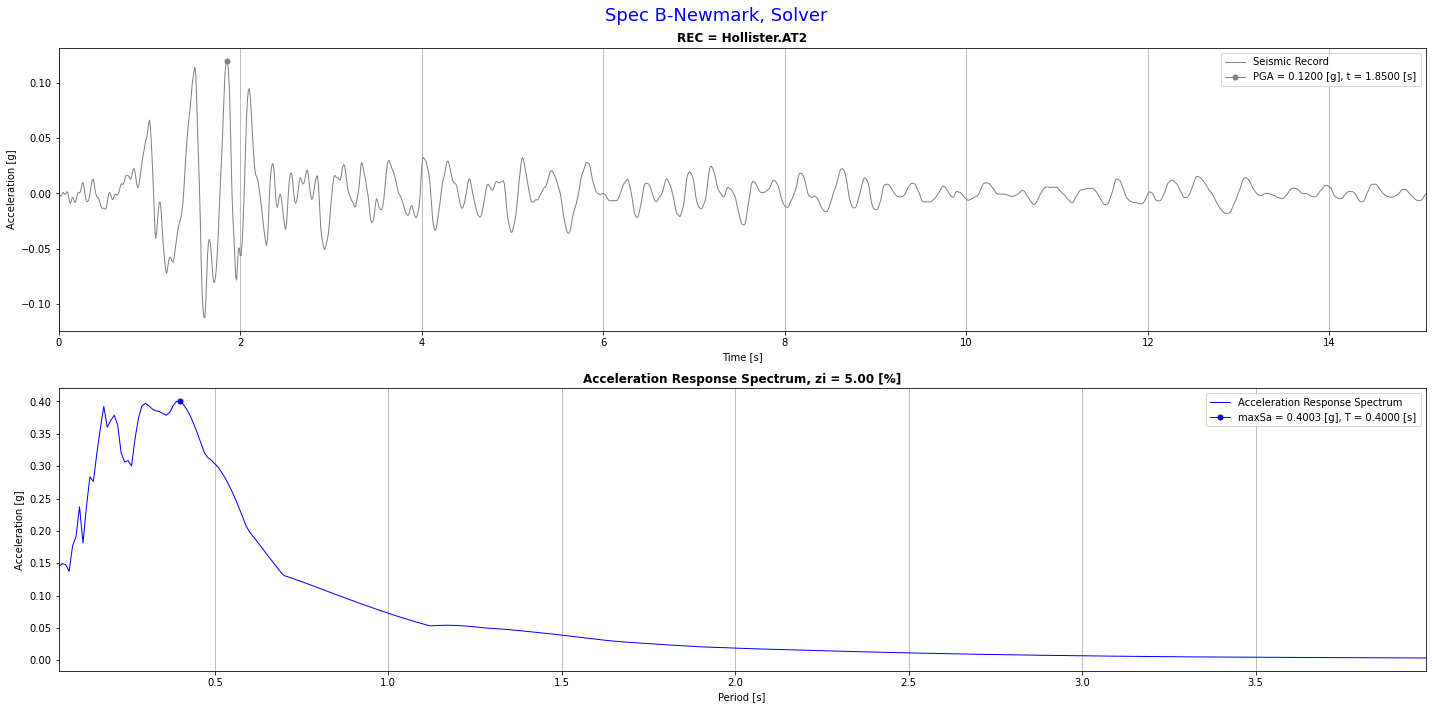

In [35]:
spec = SPEC_BNewmark(To = To, dT = dT, Tf = Tf, M = M, zi = zi,accel_record= SG, vector_time= TI,colorSeism= (0.5,0.5,0.5),
                     colorSpec= (0,0,1), title = title_record)
Sa, Ti, n = spec.Spec_Bnewmark_Jr()
SA_df = pd.DataFrame(Sa, columns= ['Max Abs Acceleraton [g]'])
TI_df = pd.DataFrame(Ti, columns= ['Period "T" [s]'])
n_df = pd.DataFrame(n, columns= ['ETA'])

spec.plot_SpecSa(Sa, Ti, n)

### UHS - NEC 2024

#### Data

In [36]:
#----------City---------
city = 'Pichinca - Quito - Cumbaya'
#---------Soild type--------
suelo = 'C'
#--------- PGA TR475 --------
z = 0.47
#--------- Amplification Soild Factors -------
zone = 'IV'
fa = 1.19
fd = 1.08
fs = 1.17
r = 1.0
Tu = 0.5139

#### Solution

In [37]:
SPEC = SPEC_NEC_2024(z = z, n = 2.40, fa = fa, fd = fd, fs = fs, dT = 0.01, Tf = 5.0, r = r,
                     city= city, soild= suelo, pga= z, zone= zone, Tu = Tu)
Sae , Tie, To, Tc, Tl, fa, fd, fs, Saeu = SPEC.spec()
Sae_df = pd.DataFrame(Sae, columns=['Response Acceleration [g]'])
Tie_df = pd.DataFrame(Tie, columns=['Period [s]'])
Sae_Tie = pd.concat([Tie_df, Sae_df], axis = 1, ignore_index= False)
Sae_Tie

To = 0.10618487394957983 [s], Tc = 0.47783193277310926 [s], Tl = 2.592 [s], fa = 1.19, fd = 1.08, fs = 1.17


,Period [s],Response Acceleration [g]
0,0.00,0.559300
1,0.01,0.633041
2,0.02,0.706782
3,0.03,0.780524
4,0.04,0.854265
...,...,...
495,4.95,0.035529
496,4.96,0.035315
497,4.97,0.035102
498,4.98,0.034891


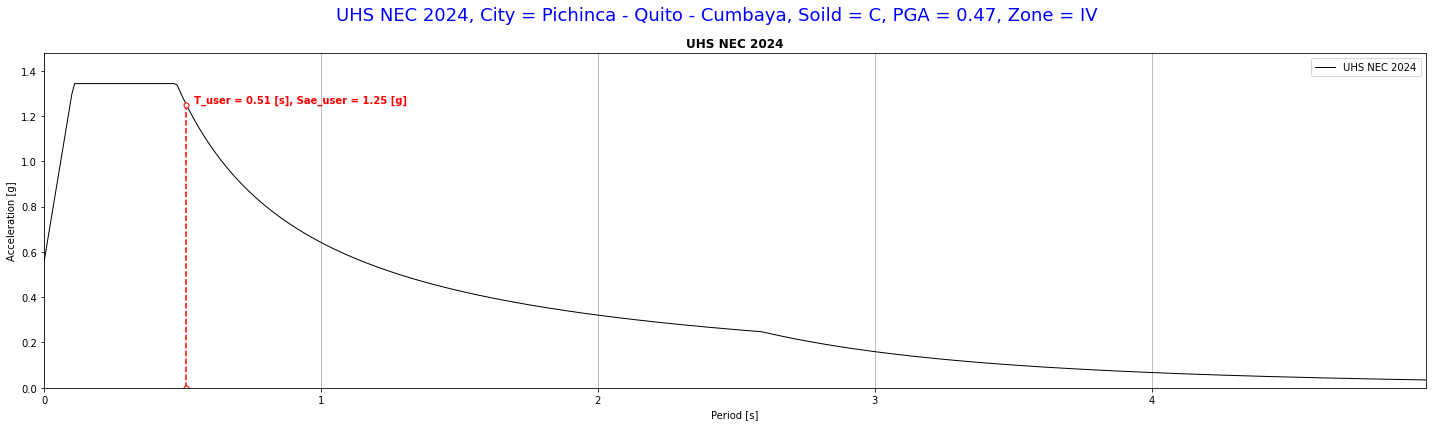

In [38]:
SPEC.plotSPECNEC(Tie, Sae, Tu, Saeu)

### Seismic Selection

#### Load Data

In [39]:
directory = Path.cwd().parent
at2_directory = directory / "records" / "UnscaledAccRecord858682"
print("=" * 120)
print("Master Directory = ", directory)
print("Records Directory = ", at2_directory)
print("=" * 120)
AT2_files = sorted(list(at2_directory.glob("*.AT2")))
AT2_files_df = pd.DataFrame([file.name for file in AT2_files], columns=["AT2 files in folder"])
AT2_files_df

Master Directory =  c:\Dropbox\Root\Github Repositories\Repo_Seismic_Desing
Records Directory =  c:\Dropbox\Root\Github Repositories\Repo_Seismic_Desing\records\UnscaledAccRecord858682


,AT2 files in folder
0,RSN1006_NORTHR_UCL-UP.AT2
1,RSN1006_NORTHR_UCL090.AT2
2,RSN1006_NORTHR_UCL360.AT2
3,RSN2627_CHICHI.03_TCU076E.AT2
4,RSN2627_CHICHI.03_TCU076N.AT2
5,RSN2627_CHICHI.03_TCU076V.AT2
6,RSN2658_CHICHI.03_TCU129E.AT2
7,RSN2658_CHICHI.03_TCU129N.AT2
8,RSN2658_CHICHI.03_TCU129V.AT2
9,RSN4843_CHUETSU_65006EW.AT2


#### ReShape Data

* UHS

In [40]:
spec = 33
T = 1.0
TIspec, SGspec = np.loadtxt(AT2_files[spec], unpack= True)

* NS

In [41]:
selected_record = 1
fsNS = 1.9658
recOriginalNS = np.loadtxt(AT2_files[selected_record], skiprows= 4)

with open(AT2_files[selected_record], "r") as file:
    recOriginalFirstRows = file.readlines()[0:4]
        
recReshapeNS = recOriginalNS.reshape(-1,1) * fsNS

recReshapeNS = recReshapeNS.ravel()
recReshapeNameNS = AT2_files[selected_record].name
print("=" * 120)
print("Selected Record Header NS:")
for row in recOriginalFirstRows:
    print(row.strip())
print("Selected Record NS (Reshape) = ", recReshapeNameNS)
print("=" * 120)

print("=" * 120)
print('Scale Factor NS = ', fsNS)
print("=" * 120)

dt = 0.02
n = len(recReshapeNS)
time = np.arange(n) * dt
recNS = np.column_stack((time, recReshapeNS))
recNS_df = pd.DataFrame(recNS, columns= ['Time [s]','Acceleration [g]'])
recNS_df

Selected Record Header NS:
PEER NGA STRONG MOTION DATABASE RECORD
Northridge-01, 1/17/1994, LA - UCLA Grounds, 90
ACCELERATION TIME SERIES IN UNITS OF G
NPTS=   3000, DT=   .0200 SEC
Selected Record NS (Reshape) =  RSN1006_NORTHR_UCL090.AT2
Scale Factor NS =  1.9658


,Time [s],Acceleration [g]
0,0.00,-0.004124
1,0.02,-0.004514
2,0.04,0.003738
3,0.06,-0.000413
4,0.08,0.007468
...,...,...
2995,59.90,0.000015
2996,59.92,0.000015
2997,59.94,0.000015
2998,59.96,0.000015


* EW

In [42]:
selected_record = 2
fsEW = 1.9658
recOriginalEW = np.loadtxt(AT2_files[selected_record], skiprows= 4)

with open(AT2_files[selected_record], "r") as file:
    recOriginalFirstRows = file.readlines()[0:4]
        
recReshapeEW = recOriginalEW.reshape(-1,1) * fsEW

recReshapeEW = recReshapeEW.ravel()
recReshapeNameEW = AT2_files[selected_record].name
print("=" * 120)
print("Selected Record Header EW:")
for row in recOriginalFirstRows:
    print(row.strip())
print("Selected Record EW (Reshape) = ", recReshapeNameEW)
print("=" * 120)

print("=" * 120)
print('Scale Factor EW = ', fsEW)
print("=" * 120)

dt = 0.02
n = len(recReshapeEW)
time = np.arange(n) * dt
recEW = np.column_stack((time, recReshapeEW))
recEW_df = pd.DataFrame(recEW, columns= ['Time [s]','Acceleration [g]'])
recEW_df

Selected Record Header EW:
PEER NGA STRONG MOTION DATABASE RECORD
Northridge-01, 1/17/1994, LA - UCLA Grounds, 360
ACCELERATION TIME SERIES IN UNITS OF G
NPTS=   3000, DT=   .0200 SEC
Selected Record EW (Reshape) =  RSN1006_NORTHR_UCL360.AT2
Scale Factor EW =  1.9658


,Time [s],Acceleration [g]
0,0.00,-0.000064
1,0.02,0.013782
2,0.04,0.009740
3,0.06,-0.004401
4,0.08,-0.014987
...,...,...
2995,59.90,-0.000030
2996,59.92,-0.000033
2997,59.94,-0.000036
2998,59.96,-0.000039


#### Solution & Plot

In [43]:
#----------Data------------#
To = 0.10
Tf = 4.0
dT = 0.01

M = 1
zi = 0.05

* NS

RSN1006_NORTHR_UCL360.AT2


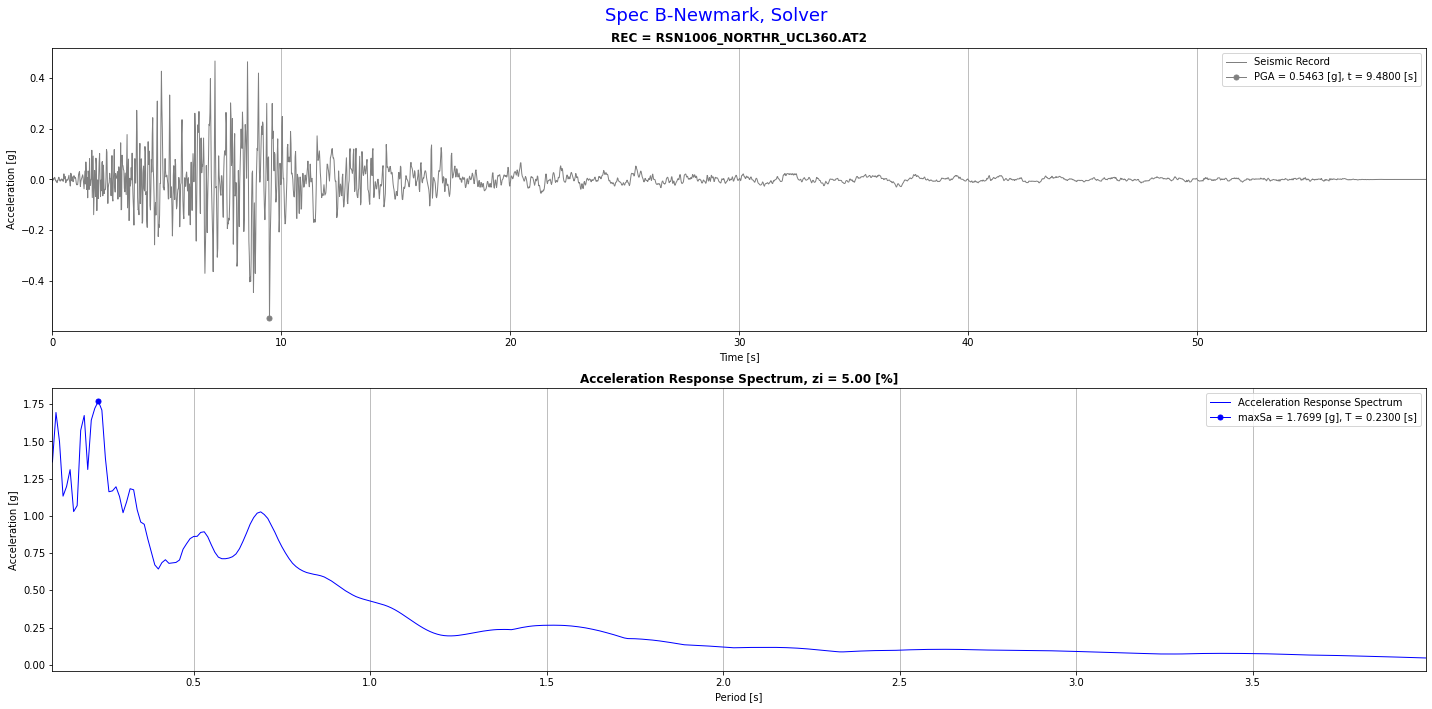

In [44]:
Title_record = AT2_files[selected_record].name
print(Title_record)
#----------Record------------#
TI = recNS[:,0]
SG = recNS[:,1]
#----------Solution------------#
spec1NS = SPEC_BNewmark(To = To, dT = dT, Tf = Tf, M = M, zi = zi,accel_record= SG, vector_time= TI,colorSeism= (0.5,0.5,0.5),
                     colorSpec= (0,0,1), title = Title_record)
SaNS, TiNS, nNS = spec1NS.Spec_Bnewmark_Jr()

spec1NS.plot_SpecSa(SaNS, TiNS, nNS)

* EW

RSN1006_NORTHR_UCL360.AT2


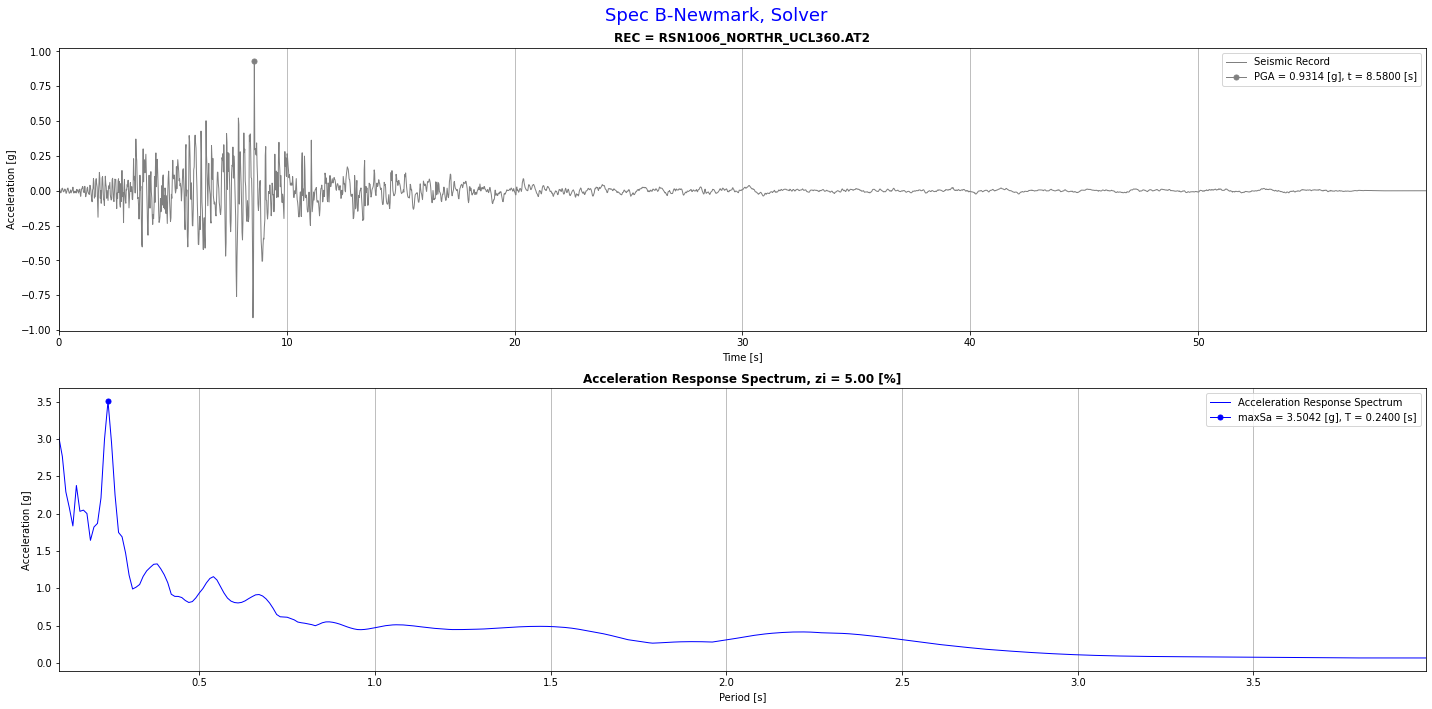

In [45]:
Title_record = AT2_files[selected_record].name
print(Title_record)
#----------Record------------#
TI = recEW[:,0]
SG = recEW[:,1]
#----------Solution------------#
spec1EW = SPEC_BNewmark(To = To, dT = dT, Tf = Tf, M = M, zi = zi,accel_record= SG, vector_time= TI,colorSeism= (0.5,0.5,0.5),
                     colorSpec= (0,0,1), title = Title_record)
SaEW, TiEW, nEW = spec1EW.Spec_Bnewmark_Jr()

spec1EW.plot_SpecSa(SaEW, TiEW, nEW)

#### SRSS

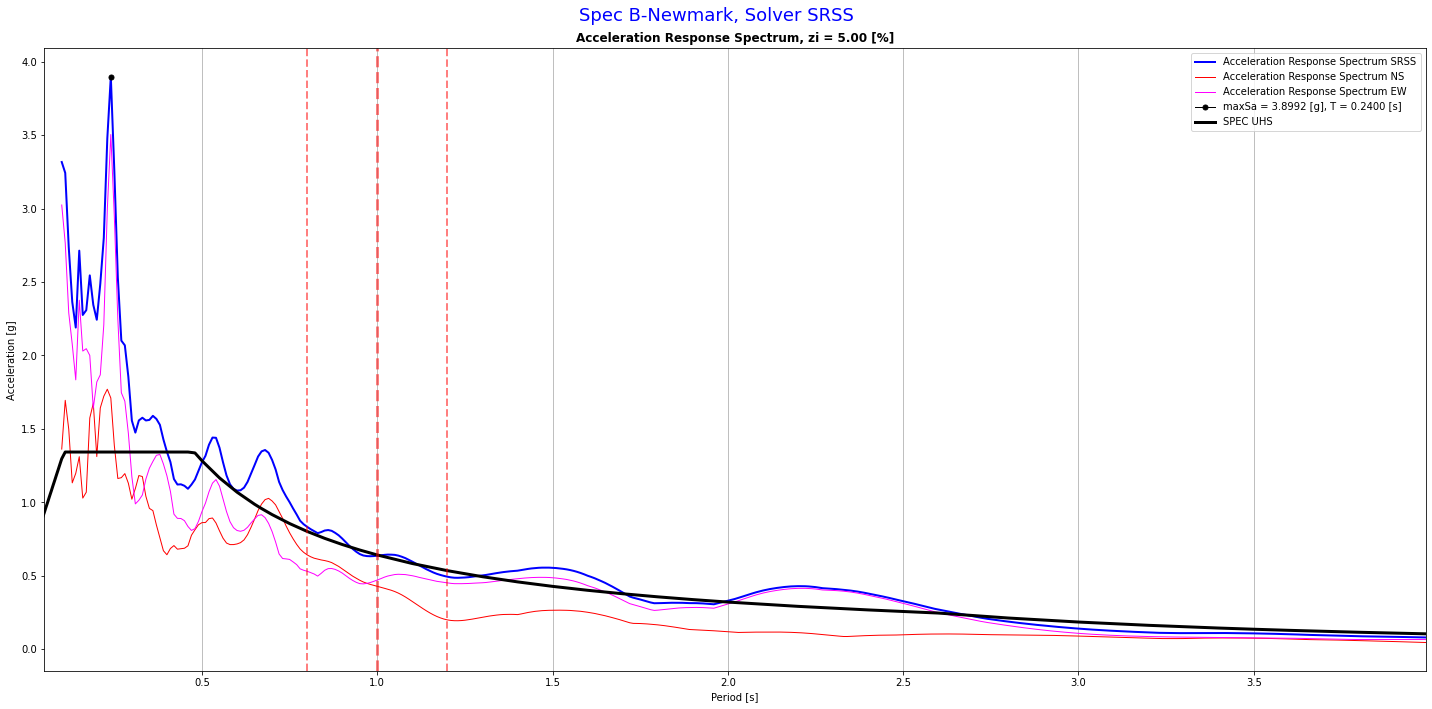

In [46]:
SaSRSS = np.sqrt(SaNS**(2) + SaEW**(2))
#----------Max Sa------------#
maxSa = np.max(np.abs(SaSRSS))
Ti_maxSa = TiEW[np.argmax(np.abs(SaSRSS))]

fig, ax = plt.subplots(1,1, figsize = (20,10))
fig.suptitle(f"Spec B-Newmark, Solver SRSS", fontsize=18, color = (0,0,1), y=0.98)
ax.plot(TiEW, SaSRSS, color = (0,0,1), alpha = 1.0 ,lw = 2.0, ls = '-', marker = 'o', 
        markersize = 0, label = 'Acceleration Response Spectrum SRSS')
ax.plot(TiEW, SaNS, color = (1,0,0), alpha = 1.0 ,lw = 1.0, ls = '-', marker = 'o', 
        markersize = 0, label = 'Acceleration Response Spectrum NS')
ax.plot(TiEW, SaEW, color = (1,0,1), alpha = 1.0 ,lw = 1.0, ls = '-', marker = 'o', 
        markersize = 0, label = 'Acceleration Response Spectrum EW')
ax.plot(Ti_maxSa, SaSRSS[np.argmax(np.abs(SaSRSS))], color = (0,0,0), alpha = 1.0 ,lw = 1.0, ls = '-', marker = 'o', 
        markersize = 5, label = f'maxSa = {maxSa:.4f} [g], T = {Ti_maxSa:.4f} [s]')

ax.plot(TIspec, SGspec, color = (0,0,0), alpha = 1.0 ,lw = 3.0, ls = '-', label = 'SPEC UHS')
ax.axvline(T, color=(1, 0, 0), alpha=0.5, linewidth=3.0, linestyle='dashed')
ax.axvline(T*0.8, color=(1, 0, 0), alpha=0.5, linewidth=2.0, linestyle='dashed')
ax.axvline(T*1.2, color=(1, 0, 0), alpha=0.5, linewidth=2.0, linestyle='dashed')

ax.set_title(f'Acceleration Response Spectrum, zi = {zi * 100:.2f} [%]', fontweight = 'bold')
ax.set_ylabel('Acceleration [g]')
ax.set_xlabel('Period [s]')
ax.grid(visible= True, axis= 'x')
ax.set_xlim(Ti[0], Ti[-1])
ax.legend(loc='best')

plt.tight_layout()
plt.show() 

### Eigen Values Eigen Vectors (Solution for MDOF Systems in Free Motion)

#### Example
![alt text](image-8.png)

#### Data

In [47]:
L = 3
a = 1.5
W = 0.05
db = 0.012
Lv = 0.50
Ev = 21000000
g = 9.8

#### Solution

In [48]:
Av = np.pi * db**2 / 4
k = Av * Ev / Lv
m = W / g

#----------- Angular Frequencies ------------
w2 = np.sqrt(m*(m*g*L + 2*a**(2)*k)) / (m*L)
w1 = np.sqrt(g*L) / L

#----------- Periods ------------
T1 = 2*np.pi / w1
T2 = 2*np.pi / w2

print('=' * 120)
print(f'w1 = ', w1)
print(f'w2 = ', w2)
print(f'T1 [s] = ', T1)
print(f'T2 [s] = ', T2)
print('=' * 120)

#----------- Vibration Modes ------------
FINw1 = np.array([
                [(2*m*L**2)**(-1/2)],
                [(2*m*L**2)**(-1/2)]
                ])

FINw2 = np.array([
                [(2*m*L**2)**(-1/2)],
                [-(2*m*L**2)**(-1/2)]
                ])

print('=' * 120)
print(f'ØN_w1 = ', FINw1)
print(f'ØN_w2 = ', FINw2)
print('=' * 120)

w1 =  1.807392228230128
w2 =  682.284324680692
T1 [s] =  3.4763817222630955
T2 [s] =  0.009209042447399195
ØN_w1 =  [[3.29983165]
 [3.29983165]]
ØN_w2 =  [[ 3.29983165]
 [-3.29983165]]


#### Stiffness and Mass Matrices
![alt text](image-9.png)

In [49]:
K = np.array([
              [a**(2)*k + m*g*L, -a**(2)*k],
              [-a**(2)*k, a**(2)*k + m*g*L]  
            ])
M = np.array([
              [m*L**(2), 0],
              [0, m*L**(2)]  
            ])

K_df = pd.DataFrame(K)
M_df = pd.DataFrame(M)
M_df

,0,1
0,0.045918,0.000000
1,0.000000,0.045918


In [50]:
analis_modal = Eig_Normalize(K,M)
w2, v, a = analis_modal.eigen()                                                                                                           # Call the function to calculate eigenvalues and eigenvectors
idx = np.argsort(w2)                                                                                                             # Sort eigenvalues in ascending order
w2 = w2[idx]                                                                                                                     # Reorganize eigenvalues
w = np.sqrt(w2)                                                                                                                  # Compute the natural angular frequencies w = sqrt(w2)
T = 2 * np.pi / w                                                                                                                # Compute the periods T = 2 * pi / w
f = 1 / T                                                                                                                        # Compute the natural frequencies f = 1 / T
v = v[:, idx]                                                                                                                    # Reorganize eigenvectors according to sorted eigenvalues
v_normalized = analis_modal.normalize_modes(v)                                                                                             # Normalize the mode shapes using the mass matrix

# Combine the results into a DataFrame
Resul_frame = pd.DataFrame({
    'Angular Frequencies': w,                                                                                                    # Column for angular frequencies w
    'Periods [s]': T,                                                                                                            # Column for periods T
    'Frequencies [Hz]': f                                                                                                        # Column for frequencies f
})

# Add normalized mode shapes to the DataFrame
for i in range(v_normalized.shape[1]):                                                                                           # Loop through each normalized mode shape
    Resul_frame[f'Normalized Mode {i+1}'] = v_normalized[:, i]                                                                   # Add each normalized mode shape as a separate column

Resul_frame.head(len(T))

,Angular Frequencies,Periods [s],Frequencies [Hz],Normalized Mode 1,Normalized Mode 2
0,1.807392,3.476382,0.287655,3.299832,3.299832
1,682.284325,0.009209,108.588923,3.299832,-3.299832
